<a href="https://colab.research.google.com/github/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection/blob/First-branch/Pipeline_2_ADASYN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Environment Setup & Library Imports`**

---



In [1]:
# PYTHON STANDARD LIBRARIES
import os
import zipfile
import warnings
from itertools import combinations

# DATA MANIPULATION
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING & DATA SPLITING
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

# PERFORMANCE METRICS & EVALUATION
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# RESAMPLING & CLASS IMBALANCE
from imblearn.over_sampling import ADASYN

# PREDICTIVE MODEL & EXPLAINABILITY
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")

# **`Data Loading & Setup`**

---



In [2]:
# Filename of the extracted PaySim CSV dataset
DATA_PATH = "PS_20174392719_1491204439457_log.csv"
# Filename of the compressed archive downloaded from Kaggle
ZIP_PATH  = "paysim1.zip"

# Check if the uncompressed CSV file already exists in the environment
if not os.path.exists(DATA_PATH):
    print("\n[INFO] Téléchargement du dataset via Kaggle API...")

    # Download the PaySim dataset directly using Kaggle API CLI
    os.system("kaggle datasets download -d ealaxi/paysim1")

    # If the ZIP file was downloaded successfully, extract its content
    if os.path.exists(ZIP_PATH):
        # Ouverture et extraction du fichier ZIP
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(".")
        print("[INFO] Extraction terminée.")

    else:
        # Raise error if the download failed or API credentials are missing
        raise FileNotFoundError(
            "Le fichier ZIP PaySim est introuvable. "
            "Vérifiez votre configuration Kaggle."
        )
# Load data into pandas
df = pd.read_csv(DATA_PATH)


[INFO] Téléchargement du dataset via Kaggle API...
[INFO] Extraction terminée.


In [3]:
# 1. Obtenir le nombre de lignes pour chaque valeur de 'step' (trié par step)
step_counts = df['step'].value_counts().sort_index().reset_index()
step_counts.columns = ['step', 'nombre_de_lignes']

# 2. Afficher les premières lignes et quelques statistiques de base
print("Aperçu des fréquences par step :")
print(step_counts.head(10))

print("\nNombre total de steps uniques :", df['step'].nunique())

Aperçu des fréquences par step :
   step  nombre_de_lignes
0     1              2708
1     2              1014
2     3               552
3     4               565
4     5               665
5     6              1660
6     7              6837
7     8             21097
8     9             37628
9    10             35991

Nombre total de steps uniques : 743


In [5]:
# 1. Agrégation par 'step' : total de transactions, nombre de fraudes et taux de fraude
step_distribution = df.groupby('step').agg(
    nombre_total=('isFraud', 'count'),
    nombre_fraudes=('isFraud', 'sum'),
    taux_fraude_pct=('isFraud', lambda x: x.mean() * 100)
).reset_index()

# 2. Afficher un aperçu des premières lignes
print("Aperçu de la distribution des fraudes par step :")
print(step_distribution.head(10))

# 3. Statistiques générales sur les fraudes par step
print("\n--- Statistiques sur les fraudes ---")
print("Total de fraudes dans le dataset :", df['isFraud'].sum())
print("Nombre de steps contenant au moins une fraude :", (step_distribution['nombre_fraudes'] > 0).sum())

Aperçu de la distribution des fraudes par step :
   step  nombre_total  nombre_fraudes  taux_fraude_pct
0     1          2708              16         0.590842
1     2          1014               8         0.788955
2     3           552               4         0.724638
3     4           565              10         1.769912
4     5           665               6         0.902256
5     6          1660              22         1.325301
6     7          6837              12         0.175516
7     8         21097              12         0.056880
8     9         37628              19         0.050494
9    10         35991              11         0.030563

--- Statistiques sur les fraudes ---
Total de fraudes dans le dataset : 8213
Nombre de steps contenant au moins une fraude : 741


# **`FEATURE & TARGET DEFINITION`**

---



In [7]:
# Categorical and numerical feature columns
CATEGORICAL_FEATURES = ['type']
NUMERICAL_FEATURES   = [
    'step', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

# Target variable (1: Fraud, 0: else)
TARGET = 'isFraud'

# Separate feature matrix (X) and target vector (y)
X = df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES]
y = df[TARGET]

# **`STRATIFIED DATASET SPLITTING`**

---



In [8]:
df_sorted = df.sort_values("step").reset_index(drop=True)

# On cherche le step qui correspond au cumul de 80% des lignes,
# pour ne pas couper une transaction au milieu d'un step
cutoff_row = int(len(df_sorted) * 0.8)
cutoff_step = df_sorted.loc[cutoff_row, "step"]

train_df = df_sorted[df_sorted["step"] <= cutoff_step]
test_df  = df_sorted[df_sorted["step"]  > cutoff_step]

X_train, y_train = train_df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES],  test_df[TARGET]

print(f"[SPLIT] Step de coupure : {cutoff_step} / {df_sorted['step'].max()}")
print(f"[SPLIT] Train : {len(train_df):,} lignes ({len(train_df)/len(df_sorted)*100:.1f}%) | "
      f"Fraudes : {train_df['isFraud'].sum():,} ({train_df['isFraud'].mean()*100:.4f}%)")
print(f"[SPLIT] Test  : {len(test_df):,} lignes ({len(test_df)/len(df_sorted)*100:.1f}%) | "
      f"Fraudes : {test_df['isFraud'].sum():,} ({test_df['isFraud'].mean()*100:.4f}%)")

[SPLIT] Step de coupure : 355 / 743
[SPLIT] Train : 5,113,884 lignes (80.4%) | Fraudes : 3,963 (0.0775%)
[SPLIT] Test  : 1,248,736 lignes (19.6%) | Fraudes : 4,250 (0.3403%)


In [4]:
# # Split dataset into 80% training and 20% testing sets
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     # 'stratify=y' ensures identical fraud ratio in both sets
#     stratify=y
# )

In [5]:
print(f"\n[SPLIT] Train : {len(X_train):,} | Test : {len(X_test):,}")
print(f"[SPLIT] Fraudes dans train : {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"[SPLIT] Fraudes dans test  : {y_test.sum():,} ({y_test.mean()*100:.4f}%)")


[SPLIT] Train : 5,090,096 | Test : 1,272,524
[SPLIT] Fraudes dans train : 6,570 (0.1291%)
[SPLIT] Fraudes dans test  : 1,643 (0.1291%)


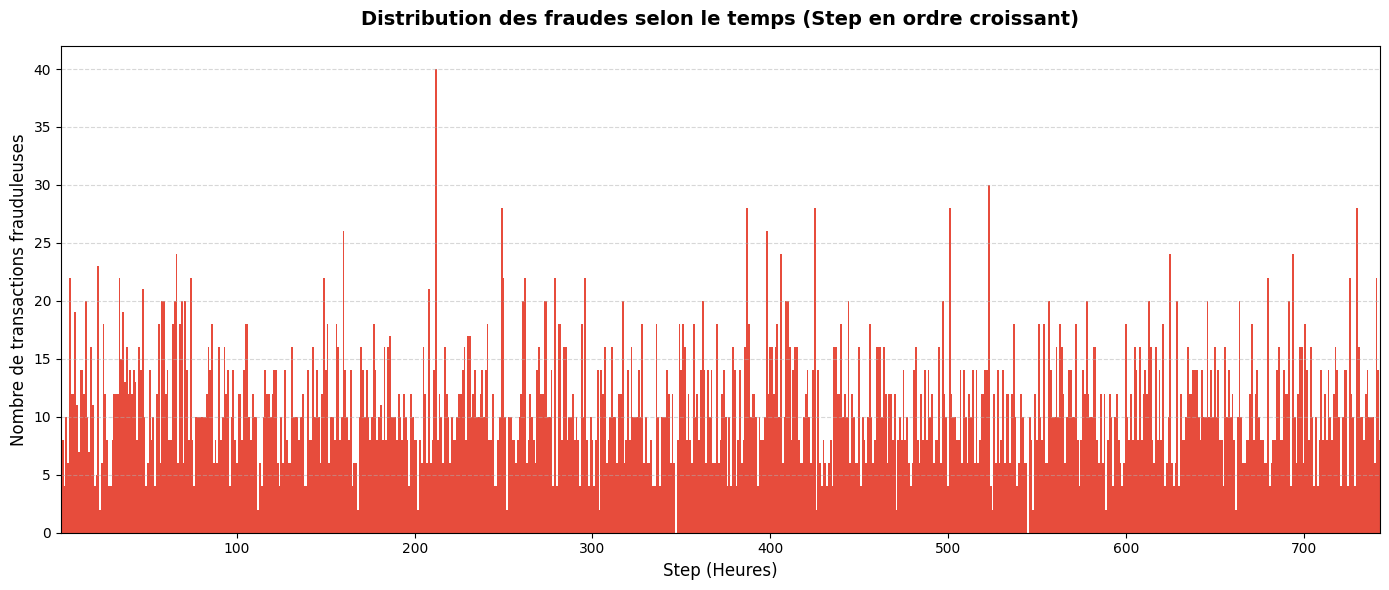

In [10]:
# 1. Agrégation du nombre de fraudes par 'step' (trié en ordre croissant)
fraud_by_step = (
    df.groupby('step')['isFraud']
    .sum()
    .reset_index()
    .sort_values('step', ascending=True)
)

# 2. Création du graphique en barres
plt.figure(figsize=(14, 6))
plt.bar(
    fraud_by_step['step'],
    fraud_by_step['isFraud'],
    color='#e74c3c',
    width=1.0,
    edgecolor='none'
)

# 3. Personnalisation du graphique
plt.title("Distribution des fraudes selon le temps (Step en ordre croissant)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Step (Heures)", fontsize=12)
plt.ylabel("Nombre de transactions frauduleuses", fontsize=12)
plt.xlim(fraud_by_step['step'].min(), fraud_by_step['step'].max())
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

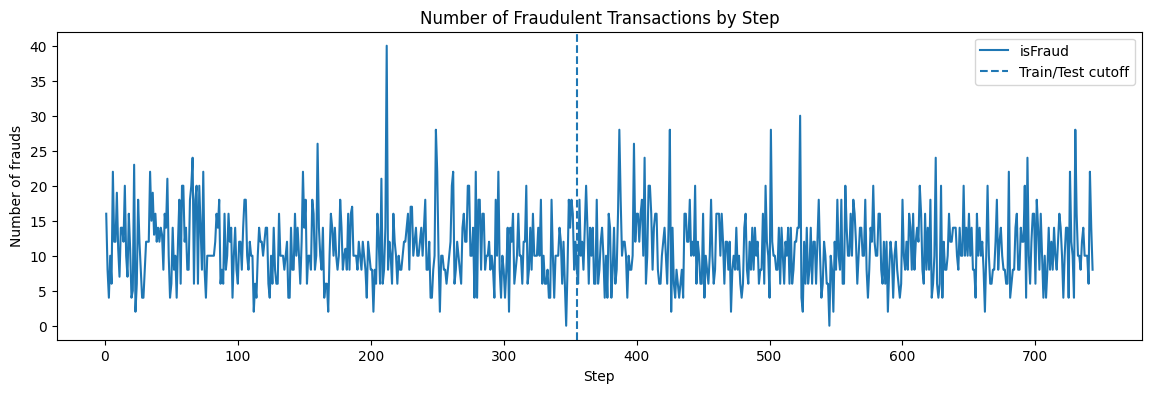

In [11]:
fraud_by_step = df.groupby("step")["isFraud"].sum()

fig, ax = plt.subplots(figsize=(14, 4))

fraud_by_step.plot(ax=ax)

ax.axvline(
    355,
    linestyle="--",
    label="Train/Test cutoff"
)

ax.set_xlabel("Step")
ax.set_ylabel("Number of frauds")
ax.set_title("Number of Fraudulent Transactions by Step")
ax.legend()

plt.show()

# **`Feature Encoding & Standardization`**

---



In [12]:
# - Categorical features: One-Hot Encoding
# - Numerical features: Standard Scaling (z-score normalization)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                # Si je rencontre une catégorie pendant le test qui n'existait pas pendant l'entraînement ne provoque pas d'erreur.
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        ),
        (
            "numerical",
            StandardScaler(),
            NUMERICAL_FEATURES
        )
    ]
)

# **`Cross-Validation Strategy`**

---



In [13]:
# Initialize Stratified 5-Fold Cross-Validation:
# - n_splits=5: Divides training data into 5 stratified folds
# - shuffle=True: Shuffles the dataset before splitting to randomize
#   data ordering and remove any inherent sorting bias
INNER_CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# **`Optuna Hyperparameter Search Space`**

---



**`1. ADASYN HYPERPARAMETER SEARCH SPACE`**

In [14]:
def get_adasyn_params(trial):
  """
    Defines the hyperparameter search space for ADASYN resampling in Optuna:
    - sampling_strategy: Desired ratio of minority to majority class
    - n_neighbors: Number of nearest neighbors used to generate synthetic samples
    - random_state: Seed for reproducible resampling
    """
  params = {
      "sampling_strategy": trial.suggest_float("adasyn_sampling_strategy", 0.1, 1.0),
      "n_neighbors": trial.suggest_int("adasyn_n_neighbors", 5, 25),
      "random_state" : 42
  }
  return params

**`2. XGBOOST HYPERPARAMETER SEARCH SPACE`**



In [15]:
def get_xgb_params(trial):
    """
    Defines the hyperparameter search space for XGBoost Classifier in Optuna:
    - n_estimators: Number of gradient boosted trees
    - max_depth: Maximum tree depth for base learners
    - learning_rate: Boosting learning rate (shrinkage) on a log scale
    - subsample: Subsample ratio of the training instances
    - gamma: Minimum loss reduction required to make a further partition
    - eval_metric: Precision-Recall AUC optimized for imbalanced data
    """

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 250, 400
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 7, 11
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.80, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 2.0, 6.0
        ),

        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1
    }

    return params

***`3. SHAP Feature Importance Calculation`***

In [16]:
def compute_shap_importance(
    model,
    # La matrice des données de validation (déjà prétraitée/encodée)
    X_validation,
    # Number of observations to sample for computing SHAP values
    sample_size=500,
    random_state=42
):
    """
    Returns Vector of feature importances:
    [importance_feature_1, importance_feature_2, ...]
    """

    # Determine sample size (ensures we don't exceed validation set length)
    n_samples = min(
        sample_size,
        X_validation.shape[0] # Total row count in X_validation
    )

    # Reproducible random sampling
    rng = np.random.RandomState(random_state)

    # Randomly select n_samples indices without replacement
    indices = rng.choice(
        # rng.choice() Sélectionne aléatoirement n_samples indices parmi le nombre total de lignes
        X_validation.shape[0],
        size=n_samples,
        replace=False
    )

    # Extract sampled rows to construct evaluation subset
    X_sample = X_validation[indices]

    # Initialize TreeExplainer and calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(
        X_sample
    )

    # Calculate mean absolute SHAP value across all sampled instances per feature
    mean_abs_shap = np.abs(
        shap_values
    ).mean(axis=0)

    return mean_abs_shap

***`4. SPEARMAN SHAP STABILITY`***

In [17]:
def compute_spearman_stability(fold_importances):
    """
    Calculates overall stability of SHAP feature explanations.

    Stability measures the mean pairwise Spearman rank correlation
    between SHAP feature importance vectors across cross-validation folds.
    """

    correlations = []

    # Toutes les combinaisons possibles de deux folds
    for importance_a, importance_b in combinations(
        # fold_importances : Une liste contenant les vecteurs d'importance SHAP calculés pour chaque fold lors de la cv
        fold_importances,
        2
    ):

        # Calculate Spearman rank correlation coefficient
        rho, _ = spearmanr(
            importance_a,
            importance_b
        )

        correlations.append(rho)

    # Compute average correlation across all fold pairs
    stability_score = np.mean(
        correlations
    )

    return stability_score

# ***`Optuna Objective Function`***

---



In [12]:
def objective(trial):

    """
    Evaluates a trial configuration using Stratified K-Fold Cross-Validation:
    1. Preprocesses training/validation folds dynamically without data leakage.
    2. Applies ADASYN oversampling on training fold.
    3. Trains XGBoost classifier and evaluates PR-AUC on validation fold.
    4. Computes SHAP feature importance per fold.
    5. Returns multi-objective targets: Mean PR-AUC and SHAP Explanation Stability.
    """
    # Sample hyperparameters from defined search spaces
    adasyn_params = get_adasyn_params(trial)
    xgb_params = get_xgb_params(trial)

    # Track metrics and feature importances across cross-validation folds
    fold_pr_auc = []
    fold_shap_importances = []
    fold_details = []

    # ============================================================
    # CROSS-VALIDATION LOOP
    # ============================================================
    for fold, (train_idx, val_idx) in enumerate(
        INNER_CV.split(X_train, y_train),
        start=1
    ):

        print( f"\nTrial {trial.number} | Fold {fold}/{INNER_CV.n_splits}")

        # Split raw fold data
        X_tr_raw = X_train.iloc[train_idx]
        X_val_raw = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Clone and fit preprocessor on training fold to prevent data leakage
        prep = clone(preprocessor)
        prep.fit( X_tr_raw, y_tr)
        X_tr = prep.transform( X_tr_raw )
        X_val = prep.transform( X_val_raw )

        # ADASYN resampler with fold-adapted random seed for reproducibility
        fold_adasyn_params = adasyn_params.copy()
        fold_adasyn_params["random_state"] = 42 + fold
        adasyn = ADASYN(**fold_adasyn_params)
        X_tr_res, y_tr_res = adasyn.fit_resample(X_tr, y_tr)

        # Instantiate and train XGBoost classifier
        model = XGBClassifier(**xgb_params)
        model.fit(X_tr_res, y_tr_res)

        # Predict probability for the positive class (fraud)
        y_val_proba = model.predict_proba(
            X_val
        )[:, 1]

        # Compute Precision-Recall AUC for the current fold
        pr_auc = average_precision_score(
            y_val,
            y_val_proba
        )

        fold_pr_auc.append(
            pr_auc
        )

        # Record fold execution metrics
        fold_details.append({
            "fold": fold,
            "pr_auc": float(pr_auc),
            "n_train_resampled": int(len(X_tr_res)),
            "n_validation": int(len(X_val_raw)),
            "fraud_train_resampled": int(y_tr_res.sum()),
            "fraud_validation": int(y_val.sum())
        })

        # Calculate SHAP feature importances on validation set
        shap_importance = compute_shap_importance(
            model=model,
            X_validation=X_val,
            sample_size=500,
            random_state=42 + fold
        )

        fold_shap_importances.append(shap_importance)
        print( f"   PR-AUC = {pr_auc:.6f}" )

    # ============================================================
    # METRIC AGGREGATION & LOGGING
    # ============================================================
    # Calculate average PR-AUC across all folds
    mean_pr_auc = np.mean(fold_pr_auc)

    # Calculate SHAP explanation stability using Spearman correlation
    shap_stability = compute_spearman_stability(fold_shap_importances)

    print( f"\nTrial {trial.number} terminé")

    # Store custom metadata attributes into Optuna trial object
    trial.set_user_attr("fold_pr_auc",[float(x) for x in fold_pr_auc])
    trial.set_user_attr("mean_pr_auc",float(mean_pr_auc))
    trial.set_user_attr("shap_stability",float(shap_stability))
    trial.set_user_attr("fold_details",fold_details)

    print( f"Mean PR-AUC       = {mean_pr_auc:.6f}")
    print( f"SHAP Stability    = {shap_stability:.6f}")

    # Return multi-objective targets to Optuna
    return (mean_pr_auc,shap_stability)

In [18]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.0 MB/s eta 0:00:00


In [15]:
import optuna
from optuna.trial import TrialState

optuna.logging.set_verbosity(optuna.logging.INFO)

# ============================================================
# SQLITE SUR GOOGLE DRIVE
# ============================================================

DB_PATH = "/content/drive/MyDrive/Optuna_Fraud_Detection_v3.db"

STORAGE = optuna.storages.RDBStorage(
    url=f"sqlite:///{DB_PATH}",

    # Heartbeat toutes les 60 secondes
    heartbeat_interval=60,

    # Si aucun heartbeat pendant 5 minutes,
    # le trial est considéré comme interrompu
    grace_period=300,

    # Évite certaines erreurs de verrouillage SQLite
    engine_kwargs={
        "connect_args": {
            "timeout": 60
        }
    }
)

STUDY_NAME = "XGBoost_PR_AUC_SHAP_Stability_ADASYN"

# ============================================================
# CREER OU RECHARGER L'ETUDE
# ============================================================

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,

    directions=[
        "maximize",   # PR-AUC
        "maximize"    # SHAP Stability
    ],

    load_if_exists=True
)

completed_trials = [
    t for t in study.trials
    if t.state == TrialState.COMPLETE
]

print("=" * 70)
print("ETUDE OPTUNA CHARGEE")
print("=" * 70)

print(f"Nom de l'étude       : {STUDY_NAME}")
print(f"Base SQLite          : {DB_PATH}")
print(f"Trials enregistrés   : {len(study.trials)}")
print(f"Trials terminés      : {len(completed_trials)}")

[I 2026-09-23 12:05:13,222] Using an existing study with `study_name='XGBoost_PR_AUC_SHAP_Stability_ADASYN'` instead of creating a new one.


ETUDE OPTUNA CHARGEE
Nom de l'étude       : XGBoost_PR_AUC_SHAP_Stability_ADASYN
Base SQLite          : /content/drive/MyDrive/Optuna_Fraud_Detection_v3.db
Trials enregistrés   : 67
Trials terminés      : 54


In [ ]:
TOTAL_TRIALS = 100

completed_trials = sum(
    t.state == TrialState.COMPLETE
    for t in study.trials
)

remaining_trials = max(
    0,
    TOTAL_TRIALS - completed_trials
)

print(f"Trials terminés actuellement : {completed_trials}")
print(f"Trials restants              : {remaining_trials}")

if remaining_trials > 0:

    study.optimize(
        objective,
        n_trials=remaining_trials
    )

else:

    print("Les 100 trials sont déjà terminés.")

Trials terminés actuellement : 46
Trials restants              : 54

Trial 58 | Fold 1/5
   PR-AUC = 0.975308

Trial 58 | Fold 2/5
   PR-AUC = 0.968030

Trial 58 | Fold 3/5
   PR-AUC = 0.978885

Trial 58 | Fold 4/5
   PR-AUC = 0.977559

Trial 58 | Fold 5/5


[I 2026-09-20 12:14:37,539] Trial 58 finished with values: [0.9750633982293195, 0.9800000000000001] and parameters: {'adasyn_sampling_strategy': 0.5490287079897948, 'adasyn_n_neighbors': 15, 'n_estimators': 385, 'max_depth': 9, 'learning_rate': 0.0999571246251812, 'subsample': 0.9179356996640189, 'gamma': 2.6708702650228875}.


   PR-AUC = 0.975535

Trial 58 terminé
Mean PR-AUC       = 0.975063
SHAP Stability    = 0.980000

Trial 59 | Fold 1/5
   PR-AUC = 0.973982

Trial 59 | Fold 2/5
   PR-AUC = 0.966900

Trial 59 | Fold 3/5
   PR-AUC = 0.980384

Trial 59 | Fold 4/5
   PR-AUC = 0.978415

Trial 59 | Fold 5/5


[I 2026-09-20 12:31:15,970] Trial 59 finished with values: [0.9749740306351743, 0.9754545454545456] and parameters: {'adasyn_sampling_strategy': 0.527173099158088, 'adasyn_n_neighbors': 19, 'n_estimators': 280, 'max_depth': 10, 'learning_rate': 0.09826733008181901, 'subsample': 0.8639406588229726, 'gamma': 2.2929193309864475}.


   PR-AUC = 0.975189

Trial 59 terminé
Mean PR-AUC       = 0.974974
SHAP Stability    = 0.975455

Trial 60 | Fold 1/5
   PR-AUC = 0.973567

Trial 60 | Fold 2/5
   PR-AUC = 0.965573

Trial 60 | Fold 3/5
   PR-AUC = 0.978091

Trial 60 | Fold 4/5
   PR-AUC = 0.975283

Trial 60 | Fold 5/5


...

   PR-AUC = 0.973056

Trial 63 terminé
Mean PR-AUC       = 0.973277
SHAP Stability    = 0.994545

Trial 64 | Fold 1/5
   PR-AUC = 0.971913

Trial 64 | Fold 2/5
   PR-AUC = 0.967727

Trial 64 | Fold 3/5
   PR-AUC = 0.977190

Trial 64 | Fold 4/5
   PR-AUC = 0.976261

Trial 64 | Fold 5/5


[I 2026-09-20 13:44:10,734] Trial 64 finished with values: [0.9735550828807191, 0.9927272727272728] and parameters: {'adasyn_sampling_strategy': 0.30933599766555553, 'adasyn_n_neighbors': 15, 'n_estimators': 264, 'max_depth': 9, 'learning_rate': 0.10491756067189074, 'subsample': 0.9503818570742866, 'gamma': 4.224831470928019}.


   PR-AUC = 0.974685

Trial 64 terminé
Mean PR-AUC       = 0.973555
SHAP Stability    = 0.992727

Trial 65 | Fold 1/5
   PR-AUC = 0.972459

Trial 65 | Fold 2/5
   PR-AUC = 0.966071

Trial 65 | Fold 3/5
   PR-AUC = 0.976166

Trial 65 | Fold 4/5
   PR-AUC = 0.975180

Trial 65 | Fold 5/5


[I 2026-09-20 13:58:49,651] Trial 65 finished with values: [0.972748036447576, 0.9881818181818183] and parameters: {'adasyn_sampling_strategy': 0.392332507835504, 'adasyn_n_neighbors': 13, 'n_estimators': 285, 'max_depth': 9, 'learning_rate': 0.07494444020918627, 'subsample': 0.9917859583186186, 'gamma': 4.864358730849017}.


   PR-AUC = 0.973864

Trial 65 terminé
Mean PR-AUC       = 0.972748
SHAP Stability    = 0.988182

Trial 66 | Fold 1/5
   PR-AUC = 0.973877

Trial 66 | Fold 2/5
   PR-AUC = 0.969131

Trial 66 | Fold 3/5
   PR-AUC = 0.978222

Trial 66 | Fold 4/5
   PR-AUC = 0.977865

Trial 66 | Fold 5/5


In [16]:
from google.colab import files

# 1. Extraction brute des données depuis Optuna
df_results = study.trials_dataframe()

# 2. Sauvegarde au format CSV (texte brut, conserve toutes les décimales)
file_name = "optuna_study_results_ADASYN.csv"
df_results.to_csv(file_name, index=False)

# 3. Téléchargement direct sur votre ordinateur
files.download(file_name)

print(f"Fichier téléchargé avec succès : {file_name}")
print(f"Nombre total de trials exportés : {len(df_results)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Fichier téléchargé avec succès : optuna_study_results_ADASYN.csv
Nombre total de trials exportés : 67


In [ ]:
import optuna

DB_PATH = "/content/drive/MyDrive/Optuna_Fraud_Detection_v3.db"
STUDY_NAME = "XGBoost_PR_AUC_SHAP_Stability_ADASYN"

study = optuna.load_study(study_name=STUDY_NAME, storage=f"sqlite:///{DB_PATH}")

print(f"Nombre total de trials enregistrés : {len(study.trials)}")

# Affichage des détails de chaque trial enregistré
for trial in study.trials:
    print(f"Trial {trial.number} | Statut: {trial.state} | Valeurs: {trial.values}")

Nombre total de trials enregistrés : 58
Trial 0 | Statut: TrialState.COMPLETE | Valeurs: [0.970094522492517, 0.9863636363636366]
Trial 1 | Statut: TrialState.COMPLETE | Valeurs: [0.9712874989909073, 0.9627272727272727]
Trial 2 | Statut: TrialState.COMPLETE | Valeurs: [0.9740384050845735, 0.970909090909091]
Trial 3 | Statut: TrialState.FAIL | Valeurs: None
Trial 4 | Statut: TrialState.COMPLETE | Valeurs: [0.9737917950999139, 0.9927272727272728]
Trial 5 | Statut: TrialState.COMPLETE | Valeurs: [0.9714595638383361, 0.9709090909090909]
Trial 6 | Statut: TrialState.COMPLETE | Valeurs: [0.9730579466903834, 0.95]
Trial 7 | Statut: TrialState.COMPLETE | Valeurs: [0.9724574477694083, 0.9827272727272728]
Trial 8 | Statut: TrialState.COMPLETE | Valeurs: [0.9697617420827619, 0.9745454545454546]
Trial 9 | Statut: TrialState.COMPLETE | Valeurs: [0.9741254799486926, 0.9800000000000001]
Trial 10 | Statut: TrialState.COMPLETE | Valeurs: [0.9684149393029774, 0.9700000000000001]
Trial 11 | Statut: TrialS

In [ ]:
from optuna.trial import TrialState

# The variable 'completed_trials' was previously redefined as an integer.
# We need to get the actual list of completed trial objects from the study.
completed_trials_list = [
    t for t in study.trials
    if t.state == TrialState.COMPLETE
]

if completed_trials_list:
    best_trial = max(completed_trials_list, key=lambda t: t.values[0])

    print(f"Meilleur Trial pour PR-AUC : Trial {best_trial.number}")
    print(f"  - PR-AUC max     : {best_trial.values[0]:.6f}")
    print(f"  - SHAP Stability : {best_trial.values[1]:.6f}")
    print(f"  - Hyperparamètres : {best_trial.params}")
else:
    print("Aucun trial complété n'a été trouvé pour déterminer le meilleur.")

Meilleur Trial pour PR-AUC : Trial 22
  - PR-AUC max     : 0.975100
  - SHAP Stability : 0.980000
  - Hyperparamètres : {'adasyn_sampling_strategy': 0.48127163300656195, 'adasyn_n_neighbors': 13, 'n_estimators': 399, 'max_depth': 7, 'learning_rate': 0.10163231970434182, 'subsample': 0.9672271963970651, 'gamma': 2.8279402869601604}


In [ ]:
for trial in study.trials:

    print(f"\nTrial {trial.number}")

    print( f"PR-AUC     : {trial.values[0]:.6f}" )

    print( f"Stabilité  : {trial.values[1]:.6f}" )

    print("\nParamètres :")

    for parameter, value in trial.params.items():

        print( f"  {parameter} = {value}")


Trial 0
PR-AUC     : 0.970095
Stabilité  : 0.986364

Paramètres :
  adasyn_sampling_strategy = 0.14069121999246215
  adasyn_n_neighbors = 10
  n_estimators = 288
  max_depth = 11
  learning_rate = 0.05267623679911499
  subsample = 0.8170281183010932
  gamma = 4.9264433108303045

Trial 1
PR-AUC     : 0.971287
Stabilité  : 0.962727

Paramètres :
  adasyn_sampling_strategy = 0.8768301845642773
  adasyn_n_neighbors = 15
  n_estimators = 351
  max_depth = 10
  learning_rate = 0.035790913972826445
  subsample = 0.883977454856261
  gamma = 4.441006706233196

Trial 2
PR-AUC     : 0.974038
Stabilité  : 0.970909

Paramètres :
  adasyn_sampling_strategy = 0.68539937468764
  adasyn_n_neighbors = 9
  n_estimators = 390
  max_depth = 7
  learning_rate = 0.12845812377750995
  subsample = 0.843650736182482
  gamma = 2.9688849721088992

Trial 3


TypeError: 'NoneType' object is not subscriptable

TOP 3 DES MEILLEURS HYPERPARAMÈTRES DU FRONT DE PARETO

🏆 Rank / Trial #37
   • Mean PR-AUC     : 0.974413
   • SHAP Stability  : 1.000000
   • Paramètres ADASYN & XGBoost :
     - adasyn_sampling_strategy: 0.37296275370566656
     - adasyn_n_neighbors: 14.0
     - n_estimators: 252.0
     - max_depth: 9.0
     - learning_rate: 0.11014223061049332
     - subsample: 0.9548612139632097
     - gamma: 3.234655102068501

🏆 Rank / Trial #42
   • Mean PR-AUC     : 0.974982
   • SHAP Stability  : 0.984545
   • Paramètres ADASYN & XGBoost :
     - adasyn_sampling_strategy: 0.590087715224279
     - adasyn_n_neighbors: 13.0
     - n_estimators: 265.0
     - max_depth: 8.0
     - learning_rate: 0.1278054038969745
     - subsample: 0.977997322412079
     - gamma: 2.9949460294302996

🏆 Rank / Trial #22
   • Mean PR-AUC     : 0.975100
   • SHAP Stability  : 0.980000
   • Paramètres ADASYN & XGBoost :
     - adasyn_sampling_strategy: 0.48127163300656195
     - adasyn_n_neighbors: 13.0
     - n_estimat

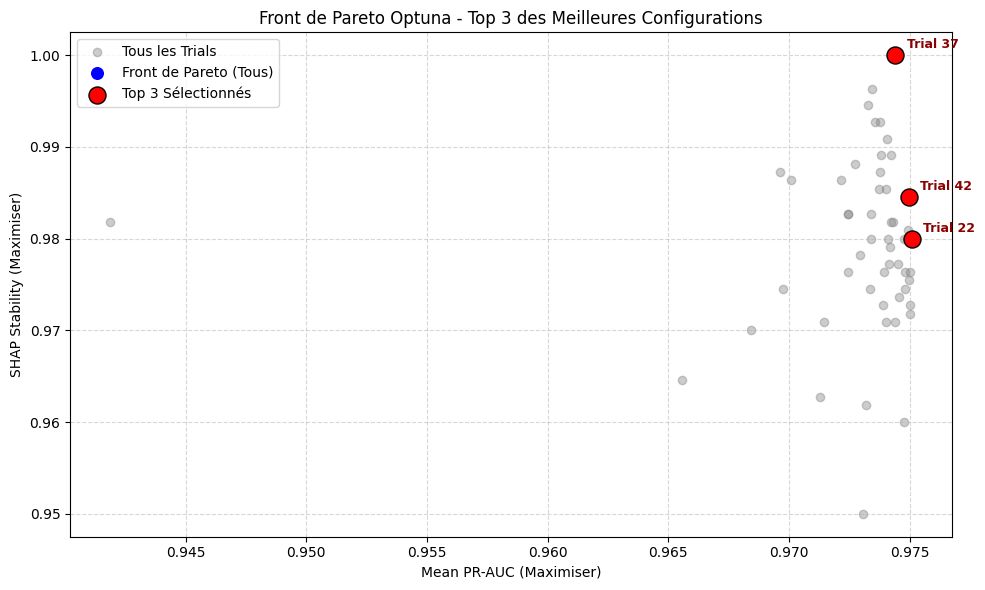

In [ ]:
# 1. Extraction des trials du front de Pareto (meilleurs compromis PR-AUC vs SHAP Stability)
best_trials = study.best_trials

# 2. Conversion des résultats du Pareto en DataFrame
pareto_data = []
for t in best_trials:
    row = {
        "trial_number": t.number,
        "mean_pr_auc": t.values[0],
        "shap_stability": t.values[1],
        **t.params
    }
    pareto_data.append(row)

df_pareto = pd.DataFrame(pareto_data)

# 3. Sélection des 3 MEILLEURS paramètres sur le Front de Pareto
# Option A : Sélection par score Normalisé / Compromis équilibré (PR-AUC + SHAP Stability)
# (Vous pouvez ajuster les poids selon votre priorité)
df_pareto["score_compromis"] = df_pareto["mean_pr_auc"] + df_pareto["shap_stability"]
top_3_trials = df_pareto.sort_values(by="score_compromis", ascending=False).head(3)

print("=" * 70)
print("TOP 3 DES MEILLEURS HYPERPARAMÈTRES DU FRONT DE PARETO")
print("=" * 70)
for idx, row in top_3_trials.iterrows():
    print(f"\n🏆 Rank / Trial #{int(row['trial_number'])}")
    print(f"   • Mean PR-AUC     : {row['mean_pr_auc']:.6f}")
    print(f"   • SHAP Stability  : {row['shap_stability']:.6f}")
    print("   • Paramètres ADASYN & XGBoost :")
    for col in df_pareto.columns:
        if col not in ["trial_number", "mean_pr_auc", "shap_stability", "score_compromis"]:
            print(f"     - {col}: {row[col]}")

# 4. Visualisation du Front de Pareto et mise en évidence des Top 3
all_completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
all_pr_auc = [t.values[0] for t in all_completed]
all_shap = [t.values[1] for t in all_completed]

plt.figure(figsize=(10, 6))

# Tous les trials terminés
plt.scatter(all_pr_auc, all_shap, color="gray", alpha=0.4, label="Tous les Trials")

# L'ensemble du front de Pareto
plt.scatter(df_pareto["mean_pr_auc"], df_pareto["shap_stability"], color="blue", s=70, label="Front de Pareto (Tous)")

# Le TOP 3 sélectionné
plt.scatter(
    top_3_trials["mean_pr_auc"],
    top_3_trials["shap_stability"],
    color="red",
    s=150,
    edgecolors="black",
    zorder=5,
    label="Top 3 Sélectionnés"
)

# Annotations pour le Top 3
for _, row in top_3_trials.iterrows():
    plt.annotate(
        f"Trial {int(row['trial_number'])}",
        (row["mean_pr_auc"], row["shap_stability"]),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        fontsize=9,
        weight="bold",
        color="darkred"
    )

plt.xlabel("Mean PR-AUC (Maximiser)")
plt.ylabel("SHAP Stability (Maximiser)")
plt.title("Front de Pareto Optuna - Top 3 des Meilleures Configurations")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

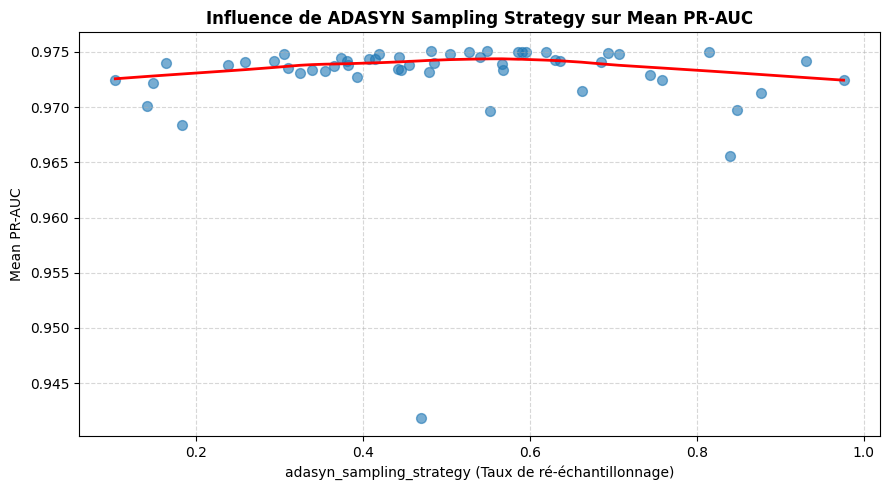

In [ ]:
# 1. Extraire les données de tous les trials terminés
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

data = []
for t in completed_trials:
    data.append({
        "adasyn_sampling_strategy": t.params["adasyn_sampling_strategy"],
        "mean_pr_auc": t.values[0]
    })

df_trials = pd.DataFrame(data)

# 2. Création de la courbe de tendance (Scatter Plot + Smooth line)
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_trials,
    x="adasyn_sampling_strategy",
    y="mean_pr_auc",
    lowess=True,  # Ligne de tendance souple (non-linéaire)
    scatter_kws={"alpha": 0.6, "color": "#1f77b4", "s": 50},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Influence de ADASYN Sampling Strategy sur Mean PR-AUC", fontsize=12, fontweight="bold")
plt.xlabel("adasyn_sampling_strategy (Taux de ré-échantillonnage)", fontsize=10)
plt.ylabel("Mean PR-AUC", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

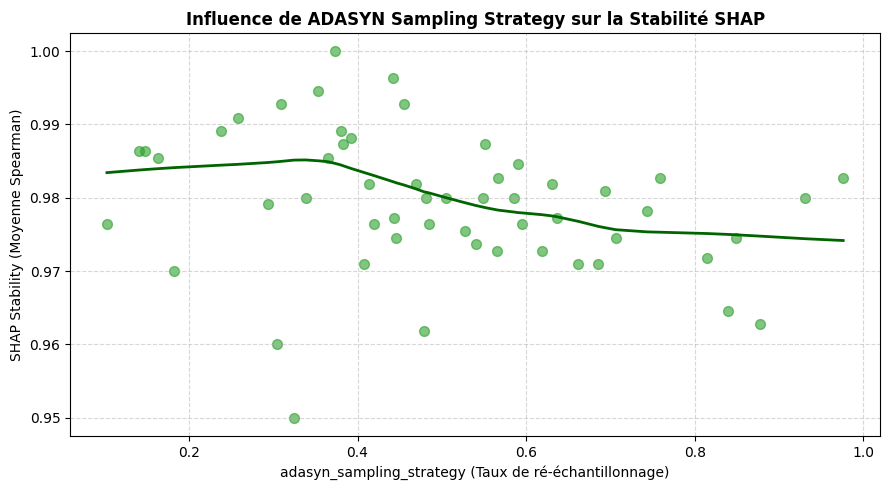

In [ ]:
# 1. Extraire les données de tous les trials terminés
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

data = []
for t in completed_trials:
    data.append({
        "adasyn_sampling_strategy": t.params["adasyn_sampling_strategy"],
        "shap_stability": t.user_attrs.get("shap_stability", t.values[1])
    })

df_trials = pd.DataFrame(data)

# 2. Graphique de tendance (Scatter Plot + Tendance)
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_trials,
    x="adasyn_sampling_strategy",
    y="shap_stability",
    lowess=True,  # Ligne de tendance non-linéaire
    scatter_kws={"alpha": 0.6, "color": "#2ca02c", "s": 50},
    line_kws={"color": "darkgreen", "linewidth": 2}
)

plt.title("Influence de ADASYN Sampling Strategy sur la Stabilité SHAP", fontsize=12, fontweight="bold")
plt.xlabel("adasyn_sampling_strategy (Taux de ré-échantillonnage)", fontsize=10)
plt.ylabel("SHAP Stability (Moyenne Spearman)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ***`Best Trial Validation & Full Model Test Evaluation`***

---



**`Optimal Parameters & Fold Evaluation`**

---



In [20]:
# ============================================================
# PARAMÈTRES OPTIMAUX (BEST TRIAL)
# ============================================================

# Optimal ADASYN resampling configuration selected from Optuna study
best_adasyn_params = {
    "sampling_strategy": 0.37296275370566656,
    "n_neighbors": 14,
}

# Optimal XGBoost classifier hyperparameters
best_xgb_params = {
    "n_estimators": 252,
    "max_depth": 9,
    "learning_rate": 0.11014223061049332,
    "subsample": 0.9548612139632097,
    "gamma": 3.234655102068501,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1
}

# ============================================================
# EVALUATION EN 5-FOLD CROSS-VALIDATION
# ============================================================
fold_results = []

for fold, (train_idx, val_idx) in enumerate(INNER_CV.split(X_train, y_train), start=1):
    print(f"Évaluation Fold {fold}/{INNER_CV.n_splits}...")

    # Split train and validation sets for the current fold
    X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Preprocessing (Fit on current training fold only to prevent data leakage)
    prep = clone(preprocessor)
    X_tr = prep.fit_transform(X_tr_raw, y_tr)
    X_val = prep.transform(X_val_raw)

    # ADASYN Oversampling with fold-specific random seed
    adasyn = ADASYN(**best_adasyn_params, random_state=42 + fold)
    X_tr_res, y_tr_res = adasyn.fit_resample(X_tr, y_tr)

    # Model instantiation and training
    model = XGBClassifier(**best_xgb_params)
    model.fit(X_tr_res, y_tr_res)

    # Predictions: Class probabilities and discrete label predictions
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)

    # Compute evaluation metrics for current fold
    fold_results.append({
        "Fold": f"Fold {fold}",
        "PR-AUC": average_precision_score(y_val, y_val_proba),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba),
        "F1-Score": f1_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred)
    })

Évaluation Fold 1/5...
Évaluation Fold 2/5...
Évaluation Fold 3/5...
Évaluation Fold 4/5...
Évaluation Fold 5/5...


**`Cross-Validation Metrics Summary`**

---



In [18]:
# SUMMARY METRICS TABLE CREATION
df_metrics = pd.DataFrame(fold_results)

# Calculate mean and standard deviation across folds
mean_metrics = df_metrics.drop(columns=["Fold"]).mean()
std_metrics = df_metrics.drop(columns=["Fold"]).std()

# Append summary rows to dataframe
df_metrics.loc[len(df_metrics)] = ["Moyenne (Mean)", *mean_metrics]
df_metrics.loc[len(df_metrics)] = ["Écart-type (Std)", *std_metrics]

# Format numerical display to 6 decimal places
df_metrics_formatted = df_metrics.copy()
for col in df_metrics_formatted.columns[1:]:
    df_metrics_formatted[col] = df_metrics_formatted[col].map(lambda x: f"{x:.6f}")

# Display final cross-validation metrics dataframe
print("\n" + "=" * 70)
print("TABLEAU DES MÉTRIQUES DE CROSS-VALIDATION (5 FOLDS)")
print("=" * 70)
display(df_metrics_formatted)


TABLEAU DES MÉTRIQUES DE CROSS-VALIDATION (5 FOLDS)


,Fold,PR-AUC,ROC-AUC,F1-Score,Precision,Recall
0,Fold 1,0.974356,0.999478,0.597749,0.428101,0.990107
1,Fold 2,0.967236,0.998319,0.615751,0.447906,0.984779
2,Fold 3,0.978509,0.999227,0.623625,0.454672,0.992390
3,Fold 4,0.976325,0.999634,0.597664,0.427448,0.993151
4,Fold 5,0.975638,0.998652,0.628075,0.459746,0.990868
5,Moyenne (Mean),0.974413,0.999062,0.612573,0.443575,0.990259
6,Écart-type (Std),0.004285,0.000559,0.014271,0.015024,0.003291


***`Final Model Training`***

---



In [21]:
# ============================================================
# FULL MODEL TRAINING & TEST SET PREPARATION
# ============================================================
print("\n[INFO] Entraînement du modèle final sur l'intégralité de X_train...")

# Global Preprocessing (Fit on full train, transform test)
X_train_prep = preprocessor.fit_transform(X_train, y_train)
X_test_prep = preprocessor.transform(X_test)

# Global ADASYN Oversampling on full preprocessed X_train
final_adasyn = ADASYN(**best_adasyn_params, random_state=42)
X_train_res, y_train_res = final_adasyn.fit_resample(X_train_prep, y_train)

# Train final XGBoost model using optimal hyperparameters
final_model = XGBClassifier(**best_xgb_params)
final_model.fit(X_train_res, y_train_res)


[INFO] Entraînement du modèle final sur l'intégralité de X_train...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=3.234655102068501, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.11014223061049332, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=252, n_jobs=-1,
              num_parallel_tree=None, ...)

**`Confusion Matrix Visualization`**

---



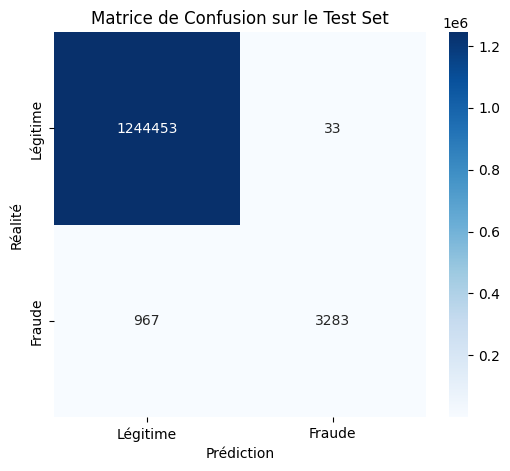

In [22]:
# Generate class predictions on the preprocessed test set
y_test_pred = final_model.predict(X_test_prep)

# Compute confusion matrix (Actual vs Predicted labels)
cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Légitime', 'Fraude'],
    yticklabels=['Légitime', 'Fraude']
)
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion sur le Test Set')
plt.show()

In [25]:
# 1. Prédictions sur le jeu de test
y_test_pred = final_model.predict(X_test_prep)
y_test_proba = final_model.predict_proba(X_test_prep)[:, 1]

# 2. Calcul des métriques
test_results = {
    "Fold": "Test Set",
    "PR-AUC": average_precision_score(y_test, y_test_proba),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "F1-Score": f1_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred)
}

# 3. Création du DataFrame et formatage à 6 décimales
df_test_metrics = pd.DataFrame([test_results])

# 4. Affichage dans le même style
print("=" * 70)
print("TABLEAU DES MÉTRIQUES SUR LE JEU DE TEST (TEST SET)")
print("=" * 70)
display(df_test_metrics.style.format({
    "PR-AUC": "{:.6f}",
    "ROC-AUC": "{:.6f}",
    "F1-Score": "{:.6f}",
    "Precision": "{:.6f}",
    "Recall": "{:.6f}"
}))

TABLEAU DES MÉTRIQUES SUR LE JEU DE TEST (TEST SET)


,Fold,PR-AUC,ROC-AUC,F1-Score,Precision,Recall
0,Test Set,0.812216,0.997140,0.288361,1.000000,0.168471


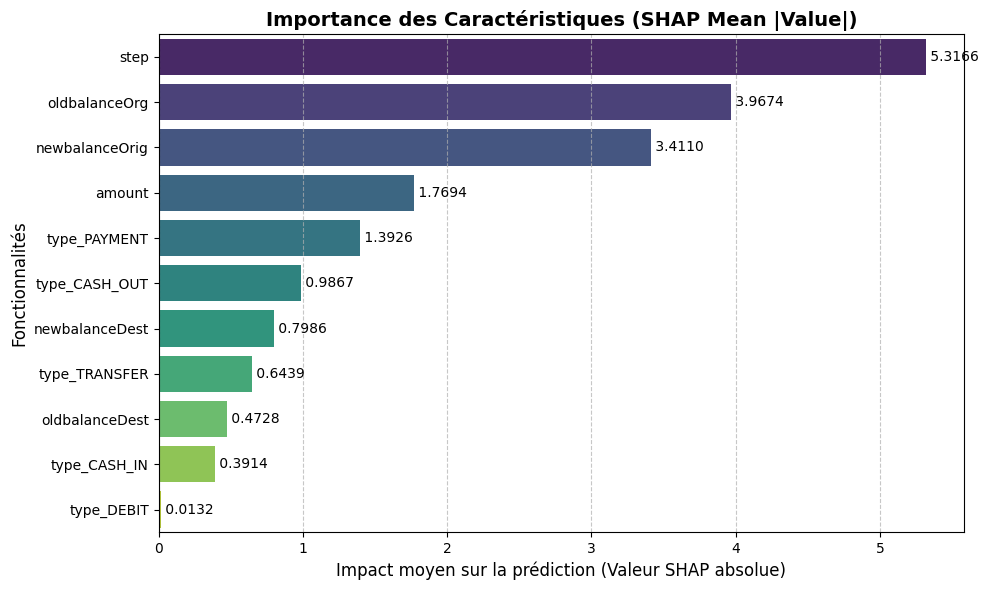

In [23]:
# 1. Extraction des noms de colonnes transformées par le preprocessor
ohe_categories = prep.named_transformers_['categorical'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(ohe_categories) + NUMERICAL_FEATURES

# 2. Calcul des valeurs SHAP sur un échantillon du jeu de test (ou de validation)
explainer = shap.TreeExplainer(model)
X_test_prep = prep.transform(X_test)

# Échantillonnage pour un calcul rapide
np.random.seed(42)
sample_indices = np.random.choice(X_test_prep.shape[0], size=min(1000, X_test_prep.shape[0]), replace=False)
X_sample = X_test_prep[sample_indices]

# SHAP values
shap_values = explainer.shap_values(X_sample)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# 3. Création du DataFrame pour le classement
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_abs_shap
}).sort_values(by='Importance', ascending=False)

# 4. Affichage du graphique en barres
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Importance des Caractéristiques (SHAP Mean |Value|)", fontsize=14, fontweight='bold')
plt.xlabel("Impact moyen sur la prédiction (Valeur SHAP absolue)", fontsize=12)
plt.ylabel("Fonctionnalités", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajout des valeurs numériques au bout des barres
for index, value in enumerate(df_importance['Importance']):
    plt.text(value, index, f" {value:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
!ls /content

sample_data


In [ ]:
!git config --global user.name "Chaabmanal2022"
!git config --global user.email "manalchaab2002@gmail.com"

In [ ]:
%cd /content

/content


In [ ]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [ ]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
%%writefile .gitignore
sample_data/
__pycache__/
*.pyc
.ipynb_checkpoints/
.env

Writing .gitignore


In [ ]:
!git checkout -b First-branch

Switched to a new branch 'First-branch'


In [ ]:
!git branch

In [ ]:
!git remote add origin https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git

In [ ]:
!git remote -v

origin	https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git (fetch)
origin	https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git (push)


In [ ]:
!git add .

In [ ]:
!git status

On branch First-branch

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .config/.last_opt_in_prompt.yaml
	new file:   .config/.last_survey_prompt.yaml
	new file:   .config/.last_update_check.json
	new file:   .config/active_config
	new file:   .config/config_sentinel
	new file:   .config/configurations/config_default
	new file:   .config/default_configs.db
	new file:   .config/gce
	new file:   .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
	new file:   .config/logs/2026.09.16/13.25.37.877256.log
	new file:   .config/logs/2026.09.16/13.26.04.283691.log
	new file:   .config/logs/2026.09.16/13.26.15.129583.log
	new file:   .config/logs/2026.09.16/13.26.17.091876.log
	new file:   .config/logs/2026.09.16/13.26.29.139725.log
	new file:   .config/logs/2026.09.16/13.26.30.459687.log
	new file:   .gitignore



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import google.colab

# Récupère le nom du notebook et recherche son chemin exact
notebook_name = "Analyse_Dataset.ipynb"
!find /content/drive/MyDrive -name "{notebook_name}" 2>/dev/null

/content/drive/MyDrive/Colab Notebooks/Analyse_Dataset.ipynb
^C


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Pipeline 2 : ADASYN.ipynb" .

In [ ]:
!git add "Pipeline 2 : ADASYN.ipynb"

In [ ]:
!git status

On branch First-branch

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .config/.last_opt_in_prompt.yaml
	new file:   .config/.last_survey_prompt.yaml
	new file:   .config/.last_update_check.json
	new file:   .config/active_config
	new file:   .config/config_sentinel
	new file:   .config/configurations/config_default
	new file:   .config/default_configs.db
	new file:   .config/gce
	new file:   .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
	new file:   .config/logs/2026.09.16/13.25.37.877256.log
	new file:   .config/logs/2026.09.16/13.26.04.283691.log
	new file:   .config/logs/2026.09.16/13.26.15.129583.log
	new file:   .config/logs/2026.09.16/13.26.17.091876.log
	new file:   .config/logs/2026.09.16/13.26.29.139725.log
	new file:   .config/logs/2026.09.16/13.26.30.459687.log
	new file:   .gitignore
	new file:   Pipeline 2 : ADASYN.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be co

In [ ]:
!git commit -m "Add pipeline 2 : ADASYN"

[First-branch (root-commit) 822374e] Add pipeline 2 : ADASYN
 17 files changed, 1026 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.09.16/13.25.37.877256.log
 create mode 100644 .config/logs/2026.09.16/13.26.04.283691.log
 create mode 100644 .config/logs/2026.09.16/13.26.15.129583.log
 create mode 100644 .config/logs/2026.09.16/13.26.17.091876.log
 create mode 100644 .config/logs/2026.09.16/13.26.29.139725.log
 create mode 100644 .config/logs/2026.09.16/13.26.30.459687.log
 create mode 100644 .gitignore
 create mode 1

In [ ]:
import getpass

TOKEN = getpass.getpass('Entrez votre GitHub Personal Access Token : ')
REPO_URL = f"https://{TOKEN}@github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git"

# Configuration de l'URL distante
!git remote set-url origin {REPO_URL}

Entrez votre GitHub Personal Access Token : ··········


In [ ]:
!git push -u origin First-branch

To https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git
 ! [rejected]        First-branch -> First-branch (fetch first)
error: failed to push some refs to 'https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
